# CNN baseline (no attention)

Trains the **plain** guided-SR CNN (`model.cnn.GuidedCNN`) on the new
4 km → 1 km MODIS LST downscaling task. Same dual-branch architecture
as the attention model but with vanilla residual blocks — establishes
how much of the gain (if any) comes from attention vs. the architecture.


## 0 — Setup

In [1]:
# Colab: install deps. Local: skip if already installed.
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q rasterio geopandas h5py huggingface_hub scikit-learn


In [2]:
# Pull the model + dataloader code. On Colab we clone; locally we assume cwd is the repo.
import os, sys
if IN_COLAB:
    if not os.path.isdir('downscaling'):
        !git clone -q https://github.com/fresleven/downscaling.git
    %cd downscaling
    sys.path.insert(0, '.')
else:
    # Add repo root to path (notebook lives in notebooks/colabs/)
    sys.path.insert(0, os.path.abspath('../..'))


In [3]:
from huggingface_hub import snapshot_download
DATA_ROOT = 'data'
snapshot_download(
    repo_id='akhot2/downscaling',
    repo_type='dataset',
    local_dir=DATA_ROOT,
)


Fetching 773 files:   0%|          | 0/773 [00:00<?, ?it/s]

'/home/fresleven/uiuc/downscaling/notebooks/colabs/data'

## 1 — Datasets

In [4]:
from model.dataset import DownscalingDataset, get_dataloaders

train_ds = DownscalingDataset(root=DATA_ROOT, split='train', download=False)
val_ds   = DownscalingDataset(root=DATA_ROOT, split='val',   download=False)
test_ds  = DownscalingDataset(root=DATA_ROOT, split='test',  download=False)

print(f'Samples — train: {len(train_ds)} ({len(train_ds.dates)} dates × {len(train_ds.split_blocks)} blocks)')
print(f'           val:  {len(val_ds)},  test: {len(test_ds)}')
print(f'HR shape: {train_ds.hr_shape},  LR shape: {train_ds.lr_shape}')
print(f'LULC classes ({len(train_ds.lulc_classes)}): {train_ds.lulc_classes.tolist()}')


Samples — train: 2300 (230 dates × 10 blocks)
           val:  536,  test: 2464
HR shape: (112, 87),  LR shape: (28, 22)
LULC classes (15): [0, 11, 21, 22, 23, 24, 31, 41, 42, 52, 71, 81, 82, 90, 95]


## 2 — Training utilities

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=0)


def make_hr_cov(batch):
    return torch.cat([batch['ndvi'], batch['dem'], batch['lulc_onehot'], batch['loc']], dim=1)


def masked_mse(pred, target, mask):
    diff2 = (pred - target) ** 2 * mask
    return diff2.sum() / mask.sum().clamp(min=1)


def augment_batch(b):
    """Random horizontal + vertical flips applied consistently to all spatial tensors."""
    lr_keys = ['lr_lst', 'lr_mask']
    hr_keys = ['hr_lst', 'lr_bicubic', 'ndvi', 'dem', 'lulc_onehot',
               'loc', 'data_mask', 'valid_mask']
    for dim in (-2, -1):
        if torch.rand(1).item() < 0.5:
            for k in lr_keys + hr_keys:
                if k in b and torch.is_tensor(b[k]):
                    b[k] = b[k].flip(dim)
    return b


@torch.no_grad()
def eval_loader(model, loader):
    """Evaluate model. R² is computed at scene level (all blocks for a date
    aggregated together) so it is comparable to the baselines notebook."""
    model.eval()
    rmses, maes = [], []
    date_preds   = defaultdict(list)
    date_targets = defaultdict(list)
    for b in loader:
        b = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in b.items()}
        pred = model(b['lr_lst'], make_hr_cov(b), b['lr_mask'], b['lr_bicubic'])
        for i in range(pred.shape[0]):
            m = b['valid_mask'][i, 0].bool()
            if not m.any():
                continue
            p = pred[i, 0][m].cpu()
            t = b['hr_lst'][i, 0][m].cpu()
            d = p - t
            rmses.append(torch.sqrt((d ** 2).mean()).item())
            maes.append(d.abs().mean().item())
            date = b['date'][i]
            date_preds[date].append(p)
            date_targets[date].append(t)
    r2s = []
    for date in date_preds:
        p_all = torch.cat(date_preds[date])
        t_all = torch.cat(date_targets[date])
        d = p_all - t_all
        ss_res = (d ** 2).sum().item()
        ss_tot = ((t_all - t_all.mean()) ** 2).sum().item()
        r2s.append(1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan'))
    return {'RMSE': float(np.mean(rmses)), 'MAE': float(np.mean(maes)),
            'R2':   float(np.nanmean(r2s))}


def train_model(model, n_epochs=60, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    history, best = [], {'val_rmse': float('inf'), 'state': None, 'epoch': -1}
    for epoch in range(n_epochs):
        model.train()
        losses = []
        for b in train_loader:
            b = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in b.items()}
            b = augment_batch(b)
            pred = model(b['lr_lst'], make_hr_cov(b), b['lr_mask'], b['lr_bicubic'])
            loss = masked_mse(pred, b['hr_lst'], b['valid_mask'])
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        sched.step()
        v = eval_loader(model, val_loader)
        history.append({'epoch': epoch, 'train_mse': float(np.mean(losses)), **v})
        if v['RMSE'] < best['val_rmse']:
            best = {'val_rmse': v['RMSE'],
                    'state': {k: t.detach().cpu().clone() for k, t in model.state_dict().items()},
                    'epoch': epoch}
        if epoch % 5 == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch:3d}  train_mse={np.mean(losses):.3f}  "
                  f"val RMSE={v['RMSE']:.3f}  MAE={v['MAE']:.3f}  R²={v['R2']:.4f}"
                  f"  (best @ {best['epoch']})")
    model.load_state_dict(best['state'])
    return model, history, best

device: cuda


## 3 — Build & train

In [6]:
from model.cnn import GuidedCNN

n_classes = train_ds.lulc_classes.shape[0]
cov_channels = 1 + 1 + n_classes + 2  # NDVI + DEM + LULC one-hot + loc (x, y)

model = GuidedCNN(cov_channels=cov_channels, base_channels=64,
                  n_lr_blocks=4, n_hr_blocks=6, dropout=0.1)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

model, history, best = train_model(model, n_epochs=60, lr=1e-3, weight_decay=1e-4)
print(f"\nBest val RMSE = {best['val_rmse']:.3f}°C @ epoch {best['epoch']}")

Params: 1,204,801
epoch   0  train_mse=43.564  val RMSE=1.252  MAE=1.000  R²=0.9435  (best @ 0)
epoch   5  train_mse=2.505  val RMSE=1.192  MAE=0.931  R²=0.9480  (best @ 1)
epoch  10  train_mse=1.692  val RMSE=1.132  MAE=0.885  R²=0.9532  (best @ 9)
epoch  15  train_mse=1.509  val RMSE=1.081  MAE=0.843  R²=0.9569  (best @ 15)
epoch  20  train_mse=1.385  val RMSE=1.095  MAE=0.854  R²=0.9565  (best @ 18)
epoch  25  train_mse=1.312  val RMSE=1.083  MAE=0.846  R²=0.9566  (best @ 18)
epoch  30  train_mse=1.205  val RMSE=1.052  MAE=0.819  R²=0.9582  (best @ 28)
epoch  35  train_mse=1.099  val RMSE=1.043  MAE=0.808  R²=0.9596  (best @ 28)
epoch  40  train_mse=1.003  val RMSE=1.077  MAE=0.834  R²=0.9561  (best @ 28)
epoch  45  train_mse=0.943  val RMSE=1.047  MAE=0.809  R²=0.9587  (best @ 28)
epoch  50  train_mse=0.896  val RMSE=1.049  MAE=0.811  R²=0.9585  (best @ 28)
epoch  55  train_mse=0.853  val RMSE=1.056  MAE=0.817  R²=0.9580  (best @ 28)
epoch  59  train_mse=0.855  val RMSE=1.053  MAE=

## 4 — Loss curves

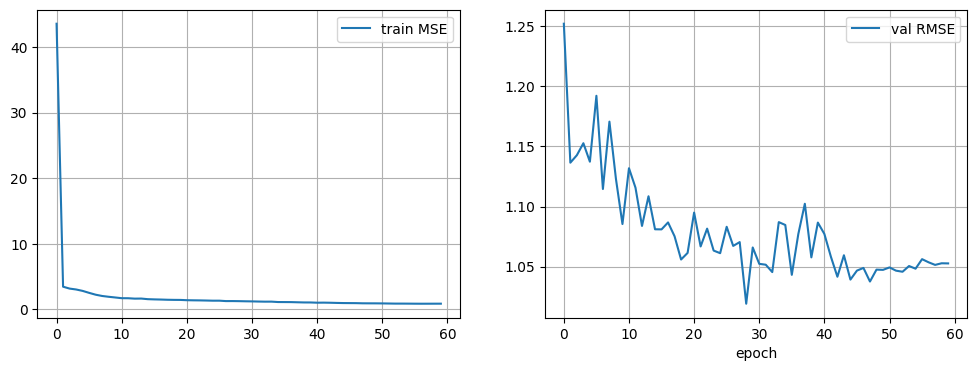

In [7]:
import matplotlib.pyplot as plt
ep = [h['epoch'] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep, [h['train_mse'] for h in history], label='train MSE'); ax[0].grid(); ax[0].legend()
ax[1].plot(ep, [h['RMSE'] for h in history], label='val RMSE'); ax[1].grid(); ax[1].legend()
ax[1].set_xlabel('epoch'); plt.show()


## 5 — Test evaluation & sample predictions

Test: {'RMSE': 1.0764740304706546, 'MAE': 0.8370884342460472, 'R2': 0.9451290934406593}


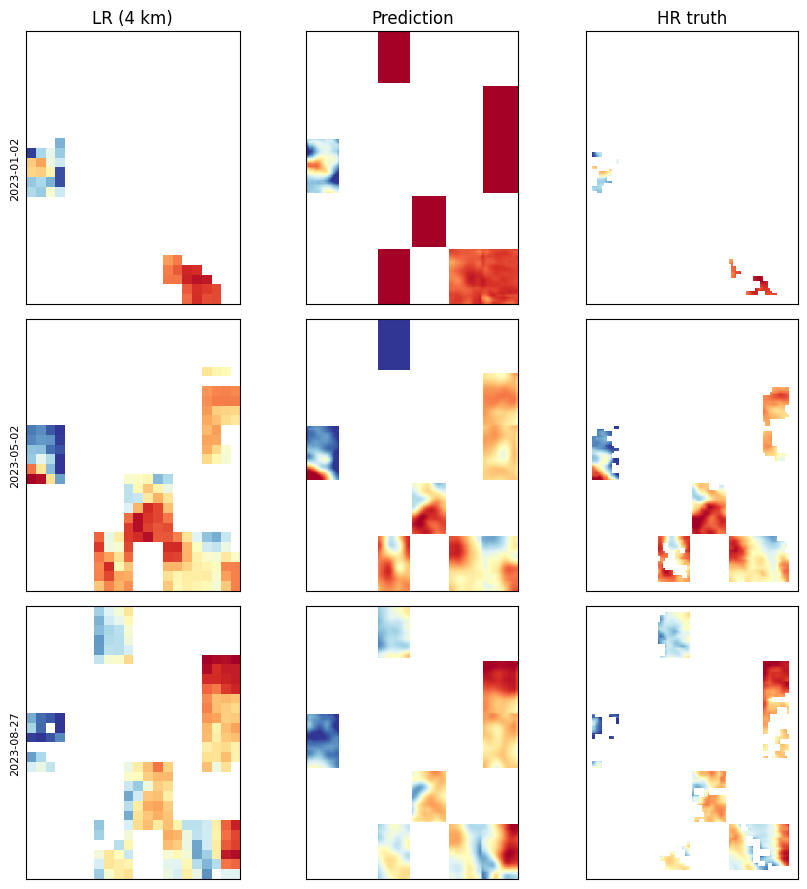

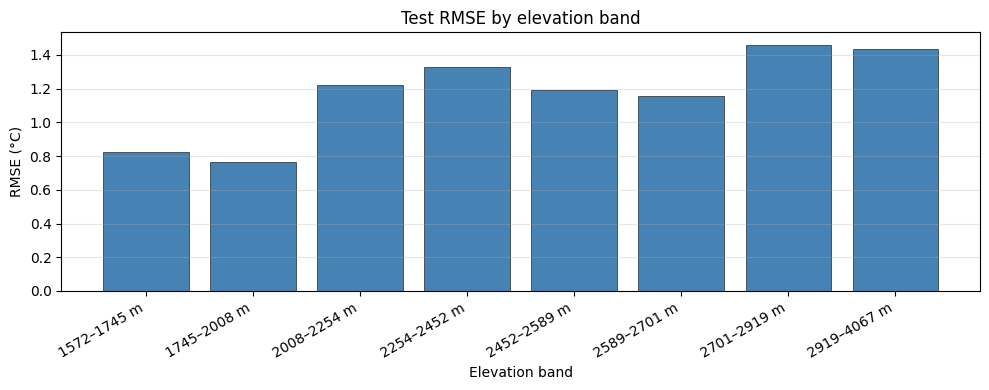

Saved rmse_by_elevation.png


In [8]:
test_metrics = eval_loader(model, test_loader)
print('Test:', test_metrics)

import matplotlib.pyplot as plt


def reconstruct_scene(model, ds, date_str, device):
    """Run model over all split blocks for `date_str`; stitch into full-scene arrays.

    Returns:
        pred  (H, W)   model prediction at HR resolution
        hr    (H, W)   HR truth, NaN where cloudy
        lr    (lH, lW) native LR scene (not upsampled), NaN where cloudy
    """
    H, W   = ds.hr_shape
    lH, lW = ds.lr_shape
    pred_scene = np.full((H,  W),  np.nan, dtype=np.float32)
    hr_scene   = np.full((H,  W),  np.nan, dtype=np.float32)
    lr_scene   = np.full((lH, lW), np.nan, dtype=np.float32)

    date_idx = next(i for i, (d, _) in enumerate(ds.dates)
                    if d.strftime('%Y-%m-%d') == date_str)
    model.eval()
    with torch.no_grad():
        for blk_idx, block_id in enumerate(ds.split_blocks):
            sample = ds[date_idx * len(ds.split_blocks) + blk_idx]

            r0, r1, c0, c1     = ds.block_bboxes[block_id]
            bH, bW             = r1 - r0, c1 - c0
            lr0, lr1, lc0, lc1 = ds.lr_block_bboxes[block_id]
            lrH, lrW           = lr1 - lr0, lc1 - lc0

            b = {k: v.unsqueeze(0).to(device) if torch.is_tensor(v) else v
                 for k, v in sample.items()}
            pr = model(b['lr_lst'], make_hr_cov(b), b['lr_mask'],
                       b['lr_bicubic']).squeeze().cpu().numpy()

            data_mask = sample['data_mask'][0, :bH,  :bW ].bool().numpy()
            lr_mask   = sample['lr_mask'][0,   :lrH, :lrW].bool().numpy()

            pred_scene[r0:r1,   c0:c1]   = pr[:bH, :bW]
            hr_scene  [r0:r1,   c0:c1]   = np.where(data_mask,
                                                     sample['hr_lst'][0, :bH, :bW].numpy(), np.nan)
            lr_scene  [lr0:lr1, lc0:lc1] = np.where(lr_mask,
                                                     sample['lr_lst'][0, :lrH, :lrW].numpy(), np.nan)

    return pred_scene, hr_scene, lr_scene


# Show 3 test dates as rows, panels as columns — same layout as baselines notebook
n_show = 3
step = max(1, len(test_ds.dates) // n_show)
show_dates = [test_ds.dates[i * step][0].strftime('%Y-%m-%d') for i in range(n_show)]

fig, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
for row, date_str in enumerate(show_dates):
    pred_sc, hr_sc, lr_sc = reconstruct_scene(model, test_ds, date_str, device)
    valid = np.isfinite(hr_sc)
    vmin = float(np.nanpercentile(hr_sc[valid], 1)) if valid.any() else 0
    vmax = float(np.nanpercentile(hr_sc[valid], 99)) if valid.any() else 1
    for col, (img, title) in enumerate([
        (lr_sc,   'LR (4 km)'),
        (pred_sc, 'Prediction'),
        (hr_sc,   'HR truth'),
    ]):
        ax = axes[row, col]
        ax.imshow(img, cmap='RdYlBu_r', vmin=vmin, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(title)
    axes[row, 0].set_ylabel(date_str, fontsize=8)
plt.tight_layout()
plt.show()

# --- RMSE per elevation band ---
elev_all, err2_all = [], []
model.eval()
with torch.no_grad():
    for b in test_loader:
        b_dev = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in b.items()}
        pr = model(b_dev['lr_lst'], make_hr_cov(b_dev), b_dev['lr_mask'],
                   b_dev['lr_bicubic']).cpu()
        for i in range(pr.shape[0]):
            m = b['valid_mask'][i, 0].bool()
            if not m.any(): continue
            elev_all.append(b['dem'][i, 0][m].numpy())
            err2_all.append((pr[i, 0][m] - b['hr_lst'][i, 0][m]).numpy() ** 2)

elev_all = np.concatenate(elev_all)
err2_all = np.concatenate(err2_all)

n_bins = 8
edges = np.percentile(elev_all, np.linspace(0, 100, n_bins + 1))
labels, rmses = [], []
for j in range(n_bins):
    sel = (elev_all >= edges[j]) & (elev_all <= edges[j + 1])
    if sel.sum() > 0:
        labels.append(f'{edges[j]:.0f}–{edges[j+1]:.0f} m')
        rmses.append(float(np.sqrt(err2_all[sel].mean())))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(labels)), rmses, color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_xlabel('Elevation band'); ax.set_ylabel('RMSE (°C)')
ax.set_title('Test RMSE by elevation band')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rmse_by_elevation.png', dpi=150)
plt.show()
print('Saved rmse_by_elevation.png')

## 6 — Save weights

In [9]:
torch.save(model.state_dict(), 'cnn_baseline.pt')
print('Saved cnn_baseline.pt')


Saved cnn_baseline.pt
